In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Загрузка данных

In [49]:

file_path = "cs-training.csv"

df = pd.read_csv("cs-training.csv")

print(df.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

# Целевая переменная (1 = дефолт, 0 = нет)

In [50]:
TARGET = "SeriousDlqin2yrs"

# 2. Предобработка

In [51]:
df = df.dropna()

In [52]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Логистическая регрессия

In [54]:
model = LogisticRegression(max_iter=1000, class_weight='balanced') # учитываем дисбаланс классов
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Вероятности дефолта

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("F1:", f1_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

ROC-AUC: 0.7861303540696346
F1: 0.3416017009213324

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91     22383
           1       0.24      0.58      0.34      1671

    accuracy                           0.85     24054
   macro avg       0.60      0.72      0.63     24054
weighted avg       0.91      0.85      0.87     24054



# 4. Настройка порога

In [56]:
threshold = 0.2  # подобран для увеличения recall

y_pred_new = (y_proba > threshold).astype(int)

In [57]:
print("F1:", f1_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

F1: 0.1317678791003927
              precision    recall  f1-score   support

           0       0.98      0.02      0.04     22383
           1       0.07      0.99      0.13      1671

    accuracy                           0.09     24054
   macro avg       0.53      0.51      0.09     24054
weighted avg       0.92      0.09      0.05     24054



In [58]:
thresholds = np.linspace(0.1, 0.5, 5)

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    print(f"Threshold: {t:.2f} | F1: {f1_score(y_test, y_pred_t):.4f}")

Threshold: 0.10 | F1: 0.1299
Threshold: 0.20 | F1: 0.1318
Threshold: 0.30 | F1: 0.1561
Threshold: 0.40 | F1: 0.2211
Threshold: 0.50 | F1: 0.3416


# 5. Матрица ошибок и ROC-кривая

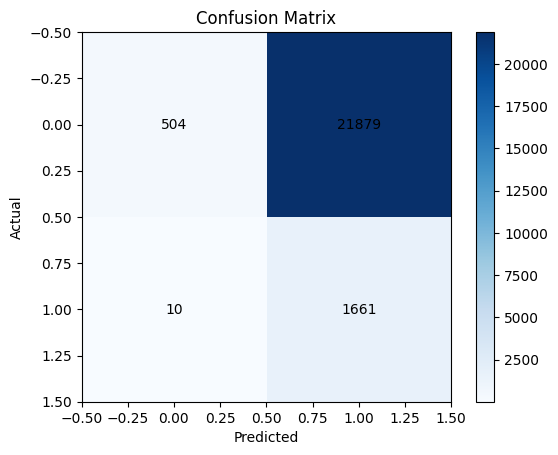

In [59]:
cm = confusion_matrix(y_test, y_pred_new)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

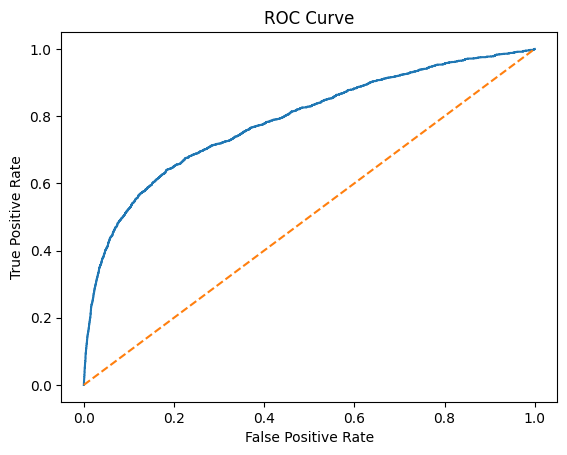

In [60]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

# 6. Случайный лес

In [61]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [62]:
y_pred_rf = (y_proba_rf > 0.2).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("F1:", f1_score(y_test, y_pred_rf))

ROC-AUC: 0.8456013426878082
F1: 0.1698601214040644


In [63]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
1,RevolvingUtilizationOfUnsecuredLines,0.337893
7,NumberOfTimes90DaysLate,0.252309
3,NumberOfTime30-59DaysPastDueNotWorse,0.227758
9,NumberOfTime60-89DaysPastDueNotWorse,0.099628
2,age,0.032878
4,DebtRatio,0.019973
5,MonthlyIncome,0.010644
6,NumberOfOpenCreditLinesAndLoans,0.008931
8,NumberRealEstateLoansOrLines,0.007705
0,Unnamed: 0,0.001449


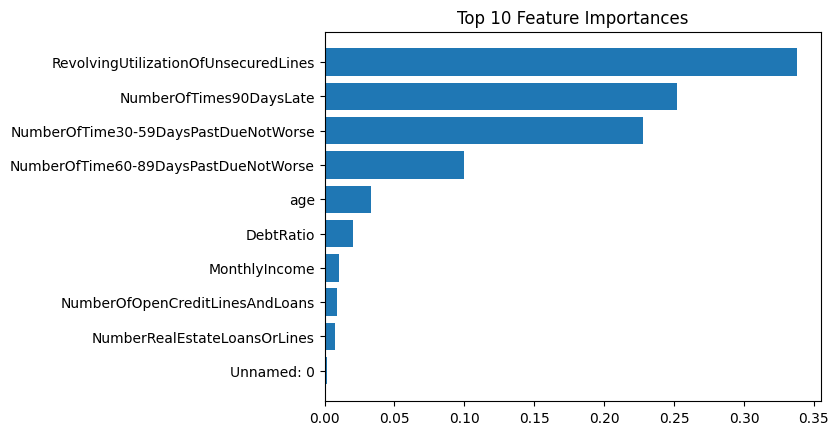

In [64]:
plt.figure()
plt.barh(feat_imp["feature"][:10], feat_imp["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

In [65]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "F1 (threshold=0.2)": [
        f1_score(y_test, (y_proba > 0.2).astype(int)),
        f1_score(y_test, (y_proba_rf > 0.2).astype(int))
    ]
})

results

,Model,ROC-AUC,F1 (threshold=0.2)
0,Logistic Regression,0.786130,0.131768
1,Random Forest,0.845601,0.169860
